# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Load Data

In [4]:
df = pd.read_csv("Stores.csv")

# Clean column names (strip spaces)

In [6]:
df.columns = df.columns.str.strip()

In [7]:
print("Columns:", df.columns.tolist())
print(df.info())
print(df.head())

Columns: ['Store ID', 'Store_Area', 'Items_Available', 'Daily_Customer_Count', 'Store_Sales']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Store ID              896 non-null    int64
 1   Store_Area            896 non-null    int64
 2   Items_Available       896 non-null    int64
 3   Daily_Customer_Count  896 non-null    int64
 4   Store_Sales           896 non-null    int64
dtypes: int64(5)
memory usage: 35.1 KB
None
   Store ID  Store_Area  Items_Available  Daily_Customer_Count  Store_Sales
0         1        1659             1961                   530        66490
1         2        1461             1752                   210        39820
2         3        1340             1609                   720        54010
3         4        1451             1748                   620        53730
4         5        1770            

# Step 3: Exploratory Data Analysis (EDA)

In [9]:
df.describe()

,Store ID,Store_Area,Items_Available,Daily_Customer_Count,Store_Sales
count,896.000000,896.000000,896.000000,896.000000,896.000000
mean,448.500000,1485.409598,1782.035714,786.350446,59351.305804
std,258.797218,250.237011,299.872053,265.389281,17190.741895
min,1.000000,775.000000,932.000000,10.000000,14920.000000
25%,224.750000,1316.750000,1575.500000,600.000000,46530.000000
50%,448.500000,1477.000000,1773.500000,780.000000,58605.000000
75%,672.250000,1653.500000,1982.750000,970.000000,71872.500000
max,896.000000,2229.000000,2667.000000,1560.000000,116320.000000


# Correlation heatmap

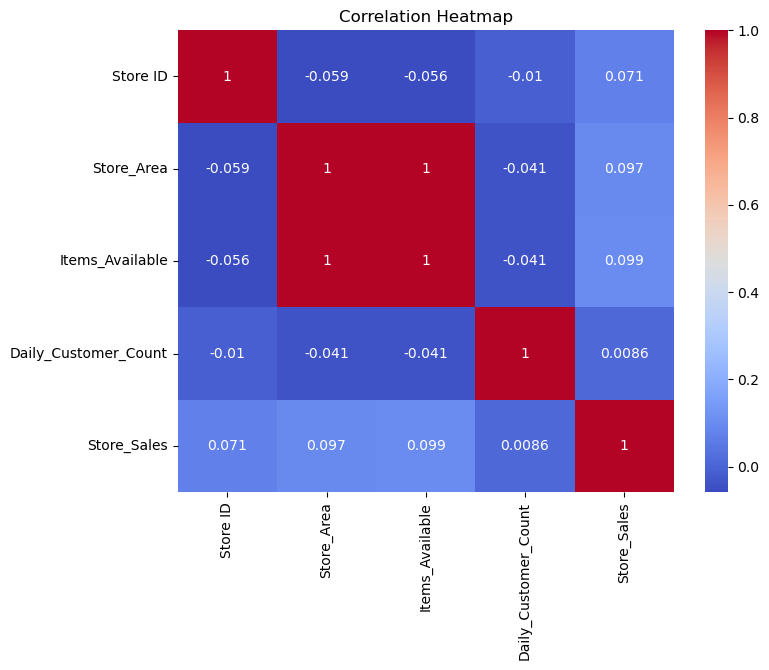

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Scatter plots

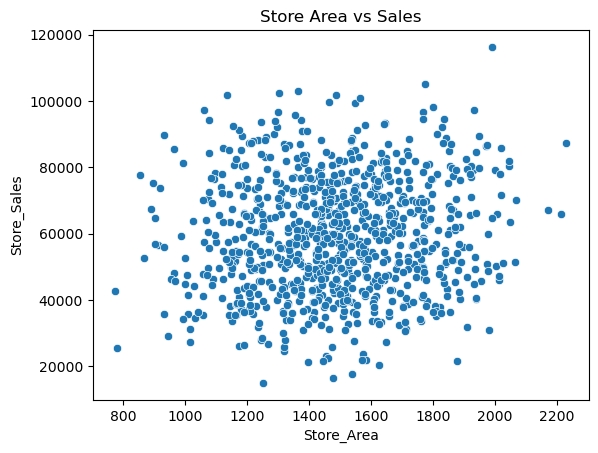

In [13]:
sns.scatterplot(x="Store_Area", y="Store_Sales", data=df)
plt.title("Store Area vs Sales")
plt.show()

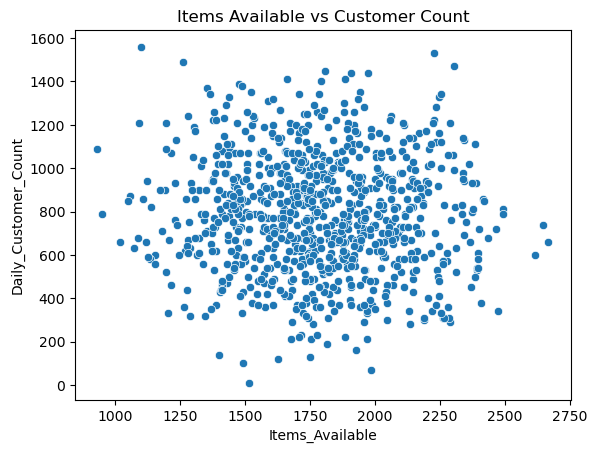

In [14]:
sns.scatterplot(x="Items_Available", y="Daily_Customer_Count", data=df)
plt.title("Items Available vs Customer Count")
plt.show()

# Step 4: Feature Engineering

In [16]:
df["Sales_per_Customer"] = df["Store_Sales"] / df["Daily_Customer_Count"]
df["Sales_per_Item"] = df["Store_Sales"] / df["Items_Available"]

# Step 5: Predictive Modeling

In [18]:
X = df[["Store_Area", "Items_Available", "Daily_Customer_Count"]]
y = df["Store_Sales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression

In [20]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lin))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lin))

Linear Regression R2: 0.006062836062981969
Linear Regression MSE: 270398518.29145896


# Random Forest

In [22]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest R2: -0.19091520720782595
Random Forest MSE: 323985981.3312778


# Step 6: Feature Importance

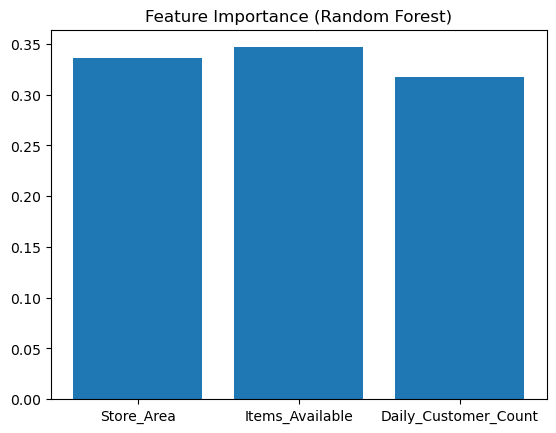

In [24]:
importances = rf_model.feature_importances_
features = X.columns
plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

# Step 7: Insights

In [26]:

top_stores = df.sort_values("Store_Sales", ascending=False).head(10)
print("Top 10 Stores by Sales:\n", 
      top_stores[["Store ID", "Store_Sales", "Store_Area", "Daily_Customer_Count"]])

Top 10 Stores by Sales:
      Store ID  Store_Sales  Store_Area  Daily_Customer_Count
649       650       116320        1989                   860
868       869       105150        1775                   980
432       433       102920        1365                   680
408       409       102310        1303                  1310
758       759       101820        1486                   820
557       558       101780        1137                   700
866       867       100900        1565                   900
166       167        99570        1465                   680
692       693        99480        1548                   480
871       872        98260        1800                  1100


# Efficiency metrics for top stores

In [28]:
top_stores_eff = top_stores[["Store ID", "Sales_per_Customer", "Sales_per_Item"]]
print("Efficiency Metrics for Top Stores:\n", top_stores_eff)

Efficiency Metrics for Top Stores:
      Store ID  Sales_per_Customer  Sales_per_Item
649       650          135.255814       48.185584
868       869          107.295918       49.976236
432       433          151.352941       62.832723
408       409           78.099237       64.467549
758       759          124.170732       57.918089
557       558          145.400000       74.075691
866       867          112.111111       54.422869
166       167          146.426471       56.477595
692       693          207.250000       53.541442
871       872           89.327273       45.532901


# Step 8: Efficiency Visualizations

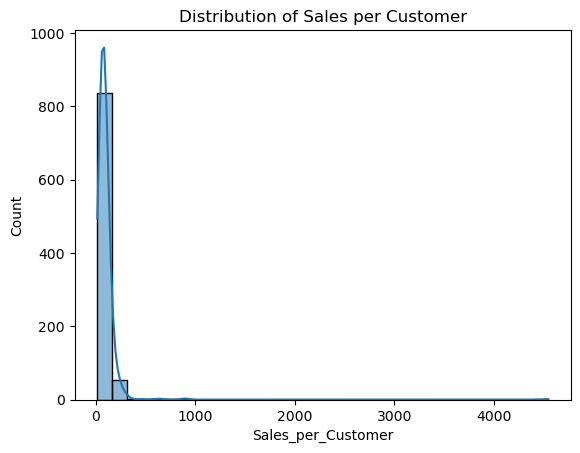

In [31]:
sns.histplot(df["Sales_per_Customer"], bins=30, kde=True)
plt.title("Distribution of Sales per Customer")
plt.show()

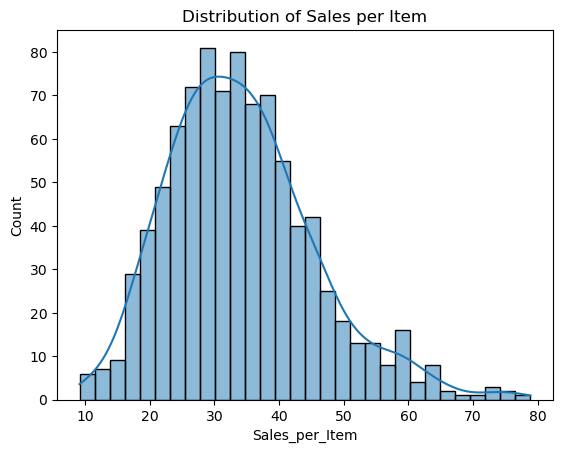

In [32]:
sns.histplot(df["Sales_per_Item"], bins=30, kde=True)
plt.title("Distribution of Sales per Item")
plt.show()